In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# !pip install -Uqq openpyxl

In [ ]:
df = pd.read_excel(r"C:\Users\G0004878\Desktop\TFT_Data\Temporal-Fusion-Transformers-Material\Fixing the bug\Final results over different iterations\Final_results_over_different_iterations.xlsx",sheet_name='Iteration 2')

In [10]:
df.columns

Index(['MONTH_NAME', 'PREDICTIONS', 'AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',
       'LAST_YEAR_SALES', 'PREDICTION_DEVIATION_FROM_AVERAGE_SALES',
       'PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES'],
      dtype='object')

In [13]:
df

,MONTH_NAME,PREDICTIONS,AVG_MONTHLY_SALES_OVER_LAST_4_YEARS,LAST_YEAR_SALES,PREDICTION_DEVIATION_FROM_AVERAGE_SALES,PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES
0,June,416260.00,407552.50,381884,0.021365,0.090017
1,July,335549.00,344535.00,306235,-0.026082,0.095724
2,August,294277.58,341248.50,304119,-0.137644,-0.032360
3,September,264781.59,296994.00,358049,-0.108461,-0.260488
4,October,1234498.63,1032598.50,1255219,0.195526,-0.016507
5,November,852511.24,678201.25,411370,0.257018,1.072371


In [35]:
def plot_deviation(data,pred_col,deviation_from_col,deviation_calc_col,file_name,fig_title):
        import matplotlib.pyplot as plt
        import matplotlib.ticker as mticker

        months = data['MONTH_NAME']
        data[deviation_calc_col] = (((data[pred_col] - data[deviation_from_col])/data[deviation_from_col])*100)
        dev_values = data[deviation_calc_col].values

        # -----------------------------------------------------------

        fig, ax = plt.subplots(figsize=(15, 6))

        ax.plot(months, dev_values, marker='o', color='#2563EB',
                linewidth=2, markersize=7, zorder=3)

        # Annotate each point
        for month, val in zip(months, dev_values):
            va = 'bottom' if val >= 0 else 'top'
            offset = 12 if val >= 0 else -12
            ax.annotate(
                f'{val:+.1f}%',
                xy=(month, val),
                xytext=(0, offset),
                textcoords='offset points',
                ha='center', va=va,
                fontsize=11, color='#2563EB', fontweight='bold'
            )

        # Zero reference line
        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

        # Shade regions
        ax.axhspan(0, max(dev_values.max(), 5), alpha=0.04, color='green')
        ax.axhspan(min(dev_values.min(), -5), 0, alpha=0.04, color='red')

        ax.set_title(fig_title,
                    fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Month', fontsize=11)
        ax.set_ylabel('Deviation (%)', fontsize=11)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)

        plt.tight_layout()
        plt.savefig(file_name, dpi=150, bbox_inches='tight')
        plt.show()

In [20]:
df.columns

Index(['MONTH_NAME', 'PREDICTIONS', 'AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',
       'LAST_YEAR_SALES', 'PREDICTION_DEVIATION_FROM_AVERAGE_SALES',
       'PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES'],
      dtype='object')

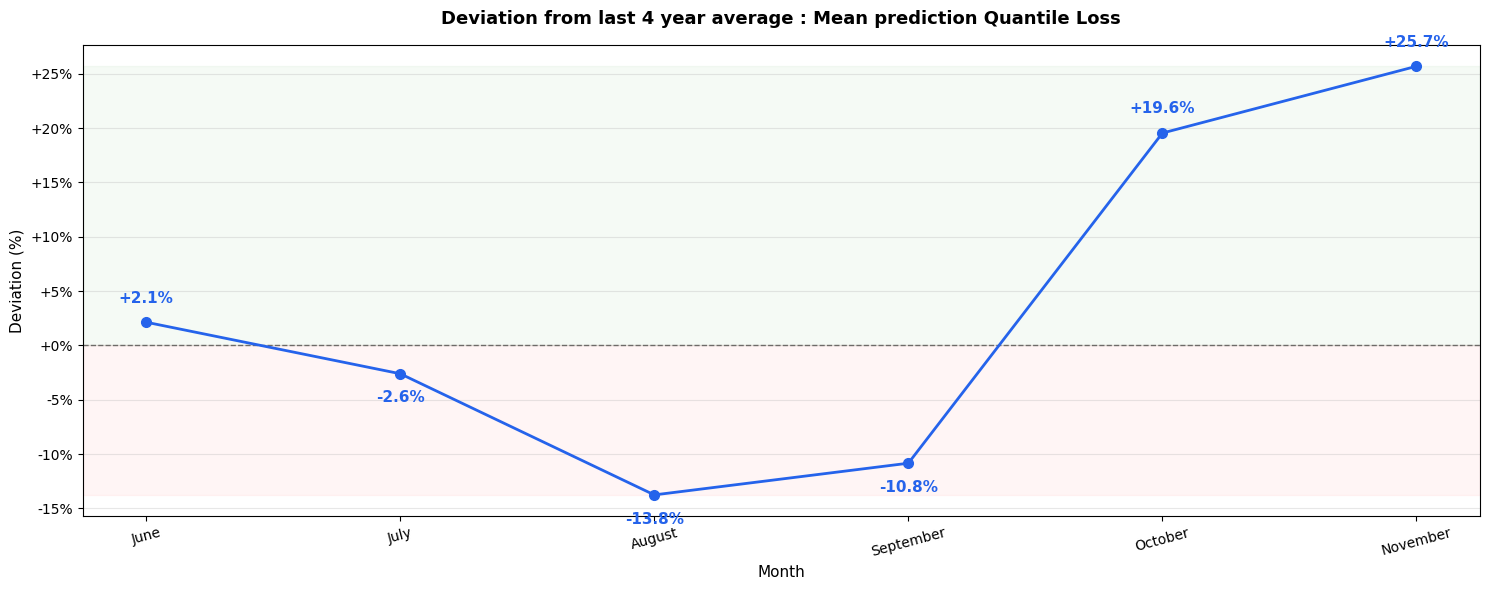

In [21]:
plot_deviation(data=df,pred_col='PREDICTIONS',deviation_from_col='AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',deviation_calc_col='DEVIATION_OF_PREDICTION_FROM_LAST_4_YEAR_AVERAGE_SALES',file_name='deviation_from_average_mean_prediction_quantile_loss',fig_title='Deviation from last 4 year average : Mean prediction Quantile Loss')

In [22]:
df.columns

Index(['MONTH_NAME', 'PREDICTIONS', 'AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',
       'LAST_YEAR_SALES', 'PREDICTION_DEVIATION_FROM_AVERAGE_SALES',
       'PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES',
       'DEVIATION_OF_PREDICTION_FROM_LAST_4_YEAR_AVERAGE_SALES'],
      dtype='object')

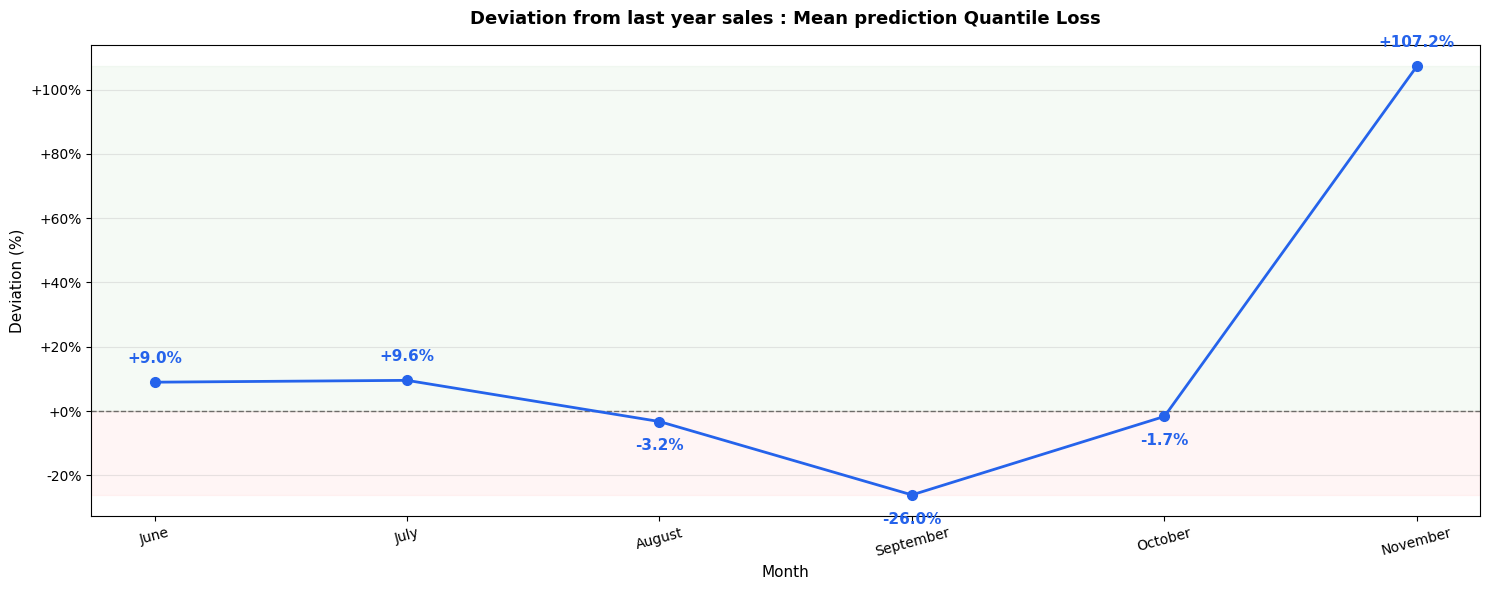

In [23]:
plot_deviation(data=df,pred_col='PREDICTIONS',deviation_from_col='LAST_YEAR_SALES',deviation_calc_col='DEVIATION_OF_PREDICTION_FROM_LAST_4_YEAR_SALES',file_name='deviation_from_last_year_sales_mean_prediction_quantile_loss',fig_title='Deviation from last year sales : Mean prediction Quantile Loss')

### Iteration 2

In [24]:
excel_file = pd.ExcelFile(r"C:\Users\yashs\OneDrive\Desktop\Learning - post job\Time Series Forecasting\TFT - Study\Fixing the bug\Final results over different iterations\Final_results_over_different_iterations.xlsx")
print(excel_file.sheet_names)

['Iteration 1', 'Iteration 2', 'Iteration 2 details', 'Iteration 3', 'Iteration 3 details', 'Iteration 4', 'Iteration 4 details', 'Pivot', 'Actual sales over last 4 years', 'Sheet9']


In [32]:
iteration_3 = pd.read_excel(r"C:\Users\yashs\OneDrive\Desktop\Learning - post job\Time Series Forecasting\TFT - Study\Fixing the bug\Final results over different iterations\Final_results_over_different_iterations.xlsx",sheet_name='Iteration 3')

In [33]:
'P10_PREDICTION' in iteration_3.columns

True

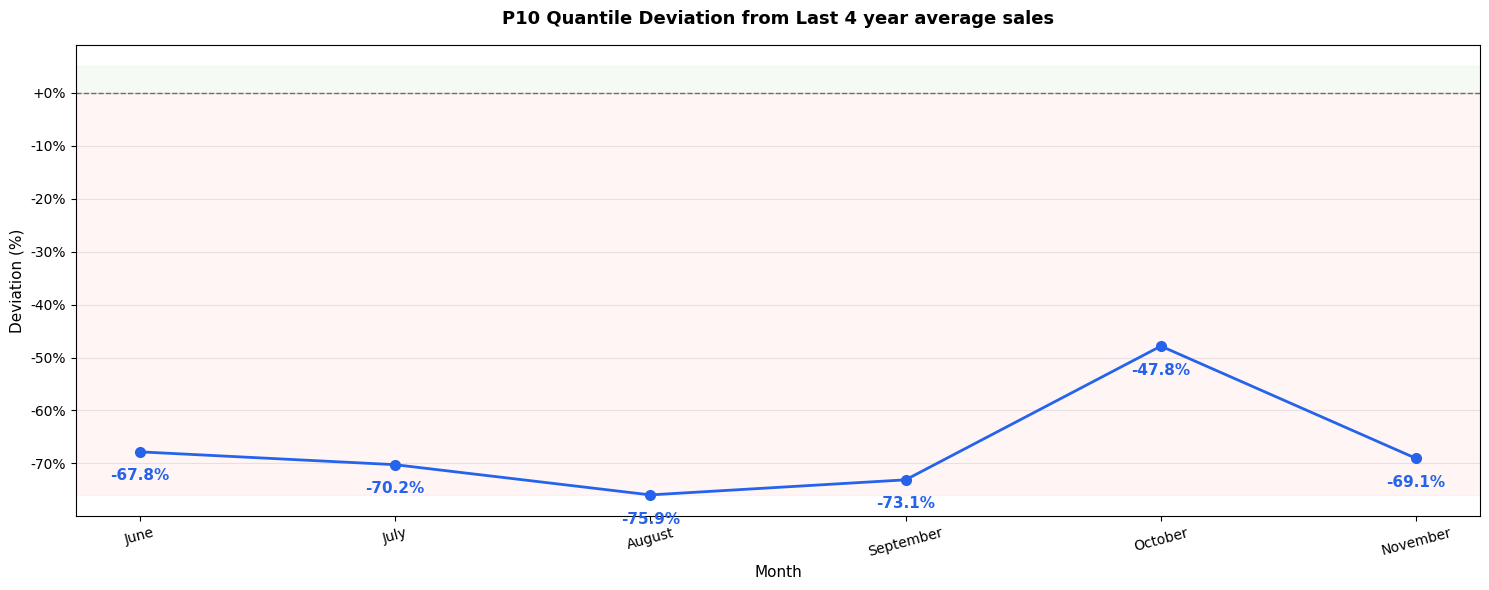

In [36]:
plot_deviation(data=iteration_3,pred_col='P10_PREDICTION',deviation_from_col='AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',deviation_calc_col='P10_DEVIATION_FROM_AVERAGE_SALES',file_name='p10_quantile_deviation_from_last_4_year_average_sales',fig_title='P10 Quantile Deviation from Last 4 year average sales')

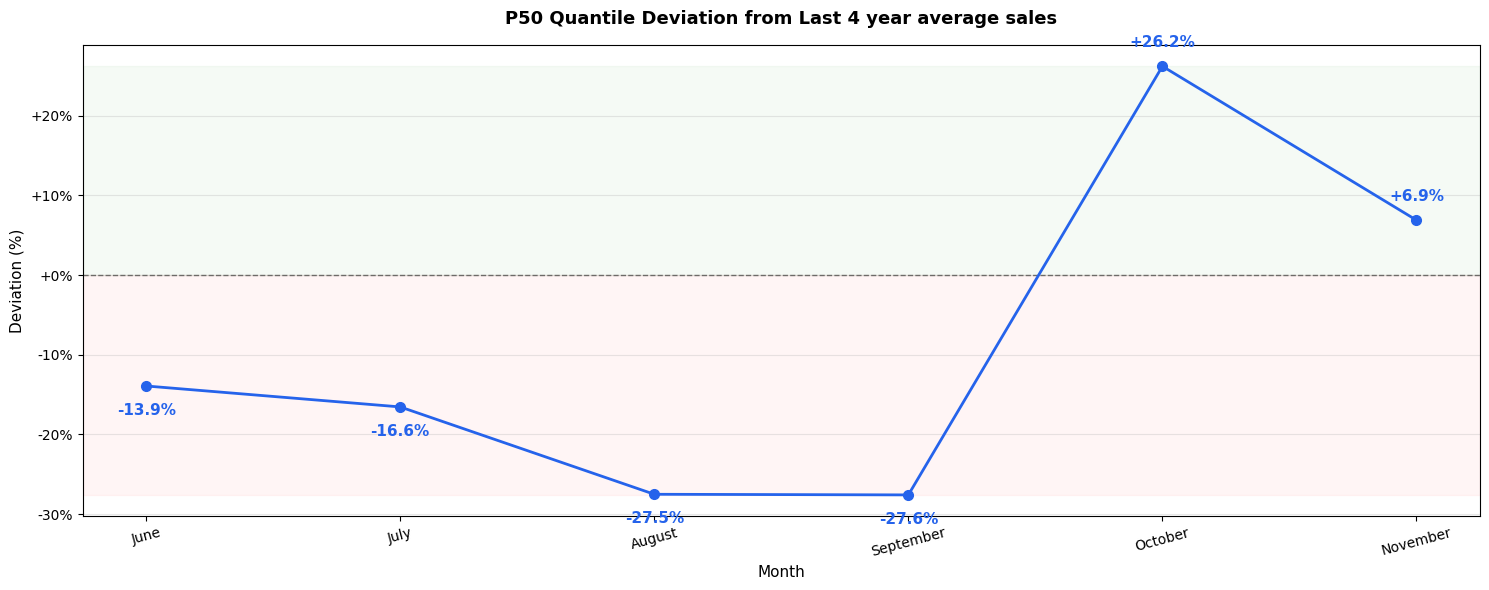

In [37]:
plot_deviation(data=iteration_3,pred_col='P50_PREDICTION',deviation_from_col='AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',deviation_calc_col='P50_DEVIATION_FROM_AVERAGE_SALES',file_name='p50_quantile_deviation_from_last_4_year_average_sales',fig_title='P50 Quantile Deviation from Last 4 year average sales')

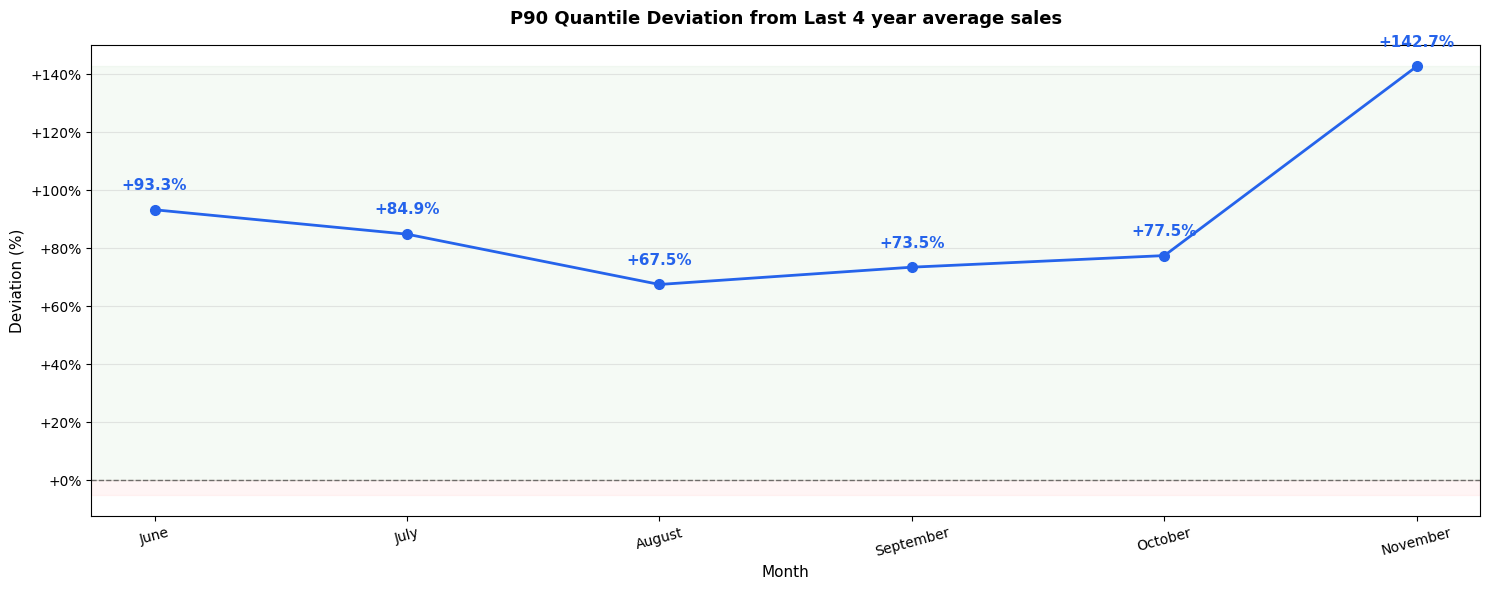

In [38]:
plot_deviation(data=iteration_3,pred_col='P90_PREDICTION',deviation_from_col='AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',deviation_calc_col='P90_DEVIATION_FROM_AVERAGE_SALES',file_name='p90_quantile_deviation_from_last_4_year_average_sales',fig_title='P90 Quantile Deviation from Last 4 year average sales')

### Iteration 4

In [39]:
iteration_4 = pd.read_excel(r"C:\Users\yashs\OneDrive\Desktop\Learning - post job\Time Series Forecasting\TFT - Study\Fixing the bug\Final results over different iterations\Final_results_over_different_iterations.xlsx",sheet_name='Iteration 4')

In [40]:
iteration_4.columns

Index(['MONTH_NAME', 'PREDICTIONS', 'AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',
       'LAST_YEAR_SALES', 'PREDICTION_DEVIATION_FROM_AVERAGE_SALES',
       'PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES'],
      dtype='object')

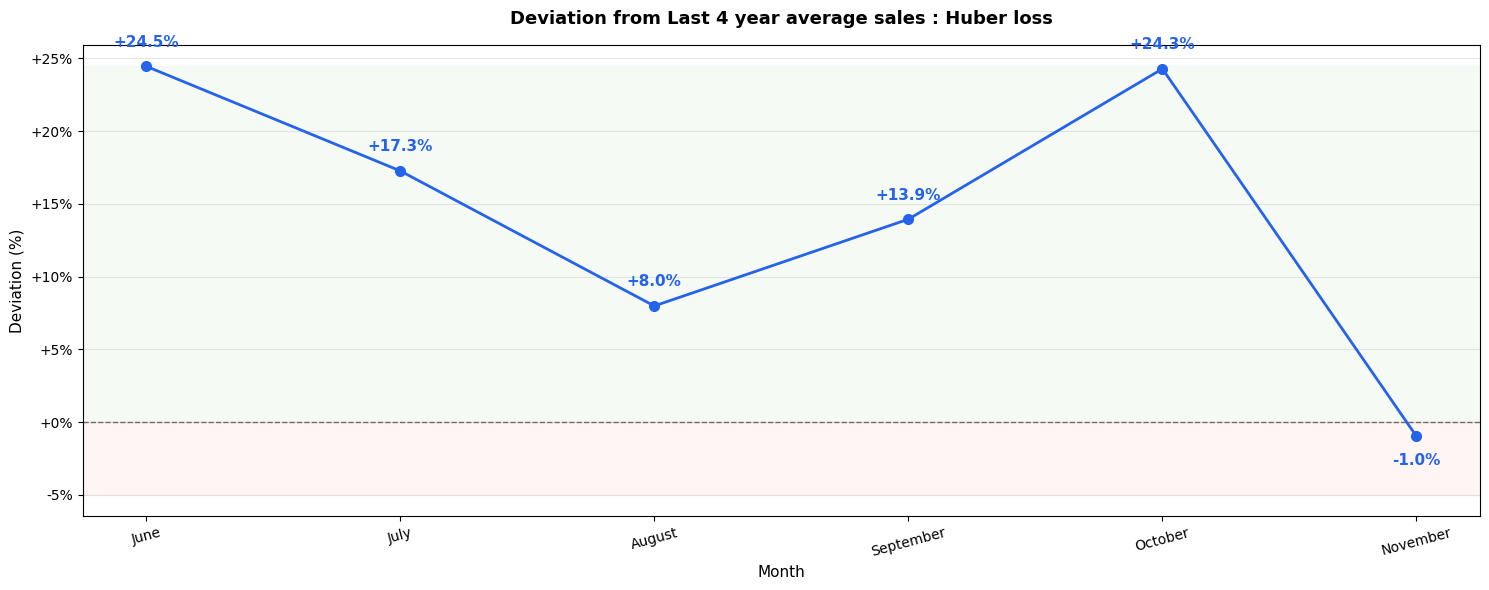

In [41]:
plot_deviation(data=iteration_4,pred_col='PREDICTIONS',deviation_from_col='AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',deviation_calc_col='DEVIATION_FROM_AVERAGE_SALES',file_name='deviation_from_last_4_year_average_sales_huber_loss',fig_title='Deviation from Last 4 year average sales : Huber loss')

In [56]:
iteration_4.columns

Index(['MONTH_NAME', 'PREDICTIONS', 'AVG_MONTHLY_SALES_OVER_LAST_4_YEARS',
       'LAST_YEAR_SALES', 'PREDICTION_DEVIATION_FROM_AVERAGE_SALES',
       'PREDICTION_DEVIATION_FROM_LAST_YEAR_SALES',
       'DEVIATION_FROM_AVERAGE_SALES'],
      dtype='object')

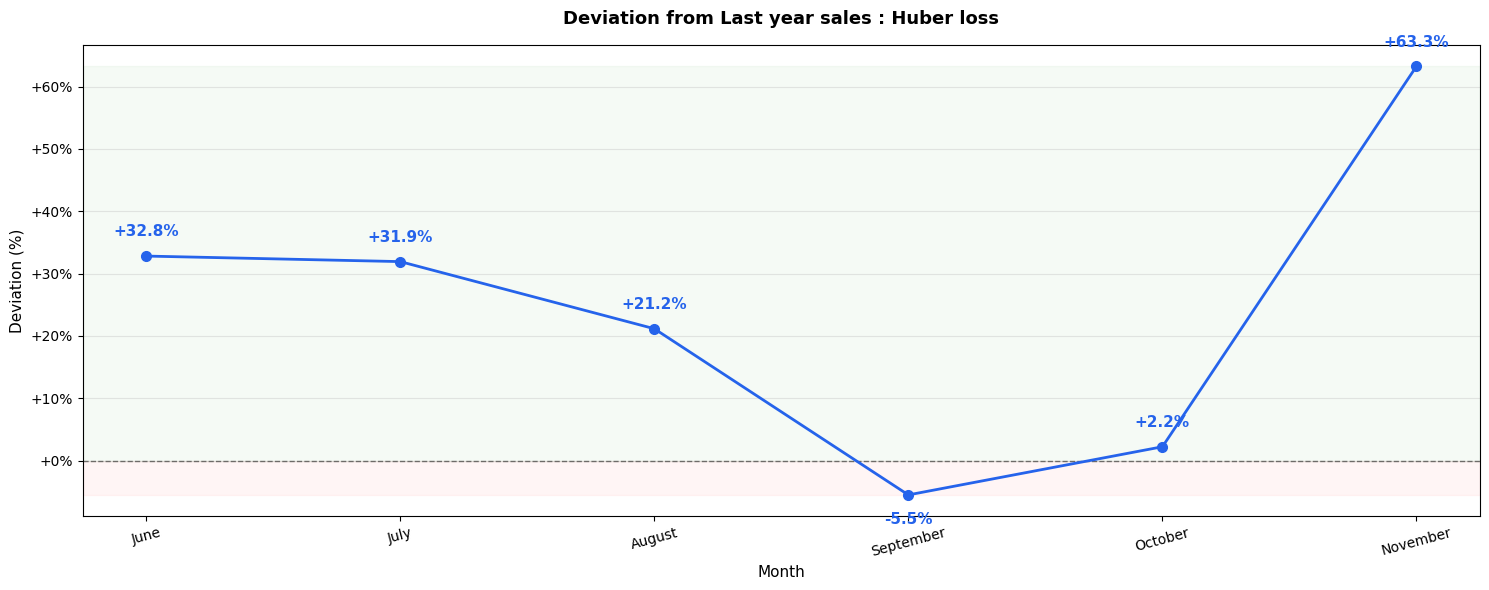

In [57]:
plot_deviation(data=iteration_4,pred_col='PREDICTIONS',deviation_from_col='LAST_YEAR_SALES',deviation_calc_col='DEVIATION_FROM_LAST_YEAR_SALES',file_name='deviation_from_last_year_sales_huber_loss',fig_title='Deviation from Last year sales : Huber loss')

In [ ]:
import pandas as pd

def generate_monthly_windows(overall_start, overall_end, input_len_months, output_len_months, step_months=1):
    """
    Generates training and prediction windows based on Month-Start (MS) frequency.
    
    Parameters:
    - overall_start: Total start date (e.g., '2026-01-01')
    - overall_end: Total end date (e.g., '2027-12-01')
    - input_len_months: Input chunk length in months
    - output_len_months: Output chunk length in months
    - step_months: Sliding step size in months (default is 1 month)
    """
    # Force inputs to Timestamp objects
    start_dt = pd.to_datetime(overall_start)
    end_dt = pd.to_datetime(overall_end)
    
    windows = []
    sample_num = 1
    
    # Initialize our sliding anchor point
    current_train_start = start_dt
    
    while True:
        # 1. Training End: Move forward by input_len_months, then step back 1 month 
        # (e.g., if start is Jan and len is 3 months, it spans Jan, Feb, Mar. End is Mar)
        current_train_end = current_train_start + pd.DateOffset(months=input_len_months - 1)
        
        # 2. Prediction Start: Exactly 1 month after Training End
        current_pred_start = current_train_end + pd.DateOffset(months=1)
        
        # 3. Prediction End: Move forward by output_len_months, then step back 1 month
        current_pred_end = current_pred_start + pd.DateOffset(months=output_len_months - 1)
        
        # Break condition: If the required prediction window goes past our overall data boundary
        if current_pred_end > end_dt:
            break
            
        # Append window limits formatted as 'YYYY-MM-DD'
        windows.append({
            "Sample number": sample_num,
            "Training start date for the window": current_train_start.strftime("%b'%y"),
            "Training end date for the window": current_train_end.strftime("%b'%y"),
            "Prediction start date for the window": current_pred_start.strftime("%b'%y"),
            "Prediction end date for the window": current_pred_end.strftime("%b'%y"),
            "Input chunk length (months)": input_len_months,
            "Output chunk length (months)": output_len_months
        })
        
        # Slide the window forward by the step size
        current_train_start += pd.DateOffset(months=step_months)
        sample_num += 1
        
    return pd.DataFrame(windows)

# ==========================================
# USER CONFIGURATION (MONTHLY)
# ==========================================
# 1. Overall boundaries (pinned to Month Start)


# # Print results
# print(f"Generated {len(df_monthly_samples)} Month-Start samples:")
# print(df_monthly_samples.to_string(index=False))

Generated 5 Month-Start samples:
 Sample number Training start date for the window Training end date for the window Prediction start date for the window Prediction end date for the window  Input chunk length (months)  Output chunk length (months)
             1                             Apr'23                           Jul'24                               Aug'24                             Jan'25                           16                             6
             2                             May'23                           Aug'24                               Sep'24                             Feb'25                           16                             6
             3                             Jun'23                           Sep'24                               Oct'24                             Mar'25                           16                             6
             4                             Jul'23                           Oct'24                             

In [53]:
TOTAL_START_DATE = "2024-06-01"
TOTAL_END_DATE = "2026-05-01"  # 2 years of data

# 2. Chunk lengths given by the user (in Months)
INPUT_CHUNK_LENGTH = 16   # Look back 12 months (1 year)
OUTPUT_CHUNK_LENGTH = 6   # Predict next 3 months (1 quarter)

# 3. Step size (Slide forward by 1 month for each subsequent sample)
STEP_SIZE = 1

# Generate the samples
df_monthly_samples_val = generate_monthly_windows(
    overall_start=TOTAL_START_DATE,
    overall_end=TOTAL_END_DATE,
    input_len_months=INPUT_CHUNK_LENGTH,
    output_len_months=OUTPUT_CHUNK_LENGTH,
    step_months=STEP_SIZE
)

In [54]:
df_monthly_samples_val

,Sample number,Training start date for the window,Training end date for the window,Prediction start date for the window,Prediction end date for the window,Input chunk length (months),Output chunk length (months)
0,1,Jun'24,Sep'25,Oct'25,Mar'26,16,6
1,2,Jul'24,Oct'25,Nov'25,Apr'26,16,6
2,3,Aug'24,Nov'25,Dec'25,May'26,16,6


In [55]:
df_monthly_samples

,Sample number,Training start date for the window,Training end date for the window,Prediction start date for the window,Prediction end date for the window,Input chunk length (months),Output chunk length (months)
0,1,Apr'23,Jul'24,Aug'24,Jan'25,16,6
1,2,May'23,Aug'24,Sep'24,Feb'25,16,6
2,3,Jun'23,Sep'24,Oct'24,Mar'25,16,6
3,4,Jul'23,Oct'24,Nov'24,Apr'25,16,6
4,5,Aug'23,Nov'24,Dec'24,May'25,16,6
